In [172]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

In [173]:
df = pd.read_csv("../data/raw/train.csv")
df.shape

(1460, 81)

In [174]:
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [175]:
df.columns
print("\n")
df.info()
print("\n")
df.describe()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  Overal

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,TotRmsAbvGrd,Fireplaces,GarageYrBlt,GarageCars,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1379.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,46.549315,567.240411,1057.429452,1162.626712,346.992466,5.844521,1515.463699,0.425342,0.057534,1.565068,0.382877,2.866438,1.046575,6.517808,0.613014,1978.506164,1.767123,472.980137,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,161.319273,441.866955,438.705324,386.587738,436.528436,48.623081,525.480383,0.518911,0.238753,0.550916,0.502885,0.815778,0.220338,1.625393,0.644666,24.689725,0.747315,213.804841,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,0.000000,0.000000,0.000000,334.000000,0.000000,0.000000,334.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,0.000000,1900.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,0.000000,223.000000,795.750000,882.000000,0.000000,0.000000,1129.500000,0.000000,0.000000,1.000000,0.000000,2.000000,1.000000,5.000000,0.000000,1961.000000,1.000000,334.500000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,0.000000,477.500000,991.500000,1087.000000,0.000000,0.000000,1464.000000,0.000000,0.000000,2.000000,0.000000,3.000000,1.000000,6.000000,1.000000,1980.000000,2.000000,480.000000,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,0.000000,808.000000,1298.250000,1391.250000,728.000000,0.000000,1776.750000,1.000000,0.000000,2.000000,1.000000,3.000000,1.000000,7.000000,1.000000,2002.000000,2.000000,576.000000,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,1474.000000,2336.000000,6110.000000,4692.000000,2065.000000,572.000000,5642.000000,3.000000,2.000000,3.000000,2.000000,8.000000,3.000000,14.000000,3.000000,2010.000000,4.000000,1418.000000,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


In [176]:
df.isnull().sum()

Id                  0
MSSubClass          0
MSZoning            0
LotFrontage       259
LotArea             0
Street              0
Alley            1369
LotShape            0
LandContour         0
Utilities           0
LotConfig           0
LandSlope           0
Neighborhood        0
Condition1          0
Condition2          0
BldgType            0
HouseStyle          0
OverallQual         0
OverallCond         0
YearBuilt           0
YearRemodAdd        0
RoofStyle           0
RoofMatl            0
Exterior1st         0
Exterior2nd         0
MasVnrType        872
MasVnrArea          8
ExterQual           0
ExterCond           0
Foundation          0
BsmtQual           37
BsmtCond           37
BsmtExposure       38
BsmtFinType1       37
BsmtFinSF1          0
BsmtFinType2       38
BsmtFinSF2          0
BsmtUnfSF           0
TotalBsmtSF         0
Heating             0
HeatingQC           0
CentralAir          0
Electrical          1
1stFlrSF            0
2ndFlrSF            0
LowQualFin

In [177]:
# tüm sutunlari goster
pd.set_option('display.max_columns', None)

print(df.isnull().sum().to_string())


Id                  0
MSSubClass          0
MSZoning            0
LotFrontage       259
LotArea             0
Street              0
Alley            1369
LotShape            0
LandContour         0
Utilities           0
LotConfig           0
LandSlope           0
Neighborhood        0
Condition1          0
Condition2          0
BldgType            0
HouseStyle          0
OverallQual         0
OverallCond         0
YearBuilt           0
YearRemodAdd        0
RoofStyle           0
RoofMatl            0
Exterior1st         0
Exterior2nd         0
MasVnrType        872
MasVnrArea          8
ExterQual           0
ExterCond           0
Foundation          0
BsmtQual           37
BsmtCond           37
BsmtExposure       38
BsmtFinType1       37
BsmtFinSF1          0
BsmtFinType2       38
BsmtFinSF2          0
BsmtUnfSF           0
TotalBsmtSF         0
Heating             0
HeatingQC           0
CentralAir          0
Electrical          1
1stFlrSF            0
2ndFlrSF            0
LowQualFin

In [178]:
# eksik degerli sutunlara bakma

missing = df.isnull().sum()
missing[missing > 0]

LotFrontage      259
Alley           1369
MasVnrType       872
MasVnrArea         8
BsmtQual          37
BsmtCond          37
BsmtExposure      38
BsmtFinType1      37
BsmtFinType2      38
Electrical         1
FireplaceQu      690
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
PoolQC          1453
Fence           1179
MiscFeature     1406
dtype: int64

In [179]:
bos_satir=df[df['Electrical'].isnull()]

print(bos_satir)

        Id  MSSubClass MSZoning  LotFrontage  LotArea Street Alley LotShape  \
1379  1380          80       RL         73.0     9735   Pave   NaN      Reg   

     LandContour Utilities LotConfig LandSlope Neighborhood Condition1  \
1379         Lvl    AllPub    Inside       Gtl       Timber       Norm   

     Condition2 BldgType HouseStyle  OverallQual  OverallCond  YearBuilt  \
1379       Norm     1Fam       SLvl            5            5       2006   

      YearRemodAdd RoofStyle RoofMatl Exterior1st Exterior2nd MasVnrType  \
1379          2007     Gable  CompShg     VinylSd     VinylSd        NaN   

      MasVnrArea ExterQual ExterCond Foundation BsmtQual BsmtCond  \
1379         0.0        TA        TA      PConc       Gd       TA   

     BsmtExposure BsmtFinType1  BsmtFinSF1 BsmtFinType2  BsmtFinSF2  \
1379           No          Unf           0          Unf           0   

      BsmtUnfSF  TotalBsmtSF Heating HeatingQC CentralAir Electrical  \
1379        384          384    

## Data Preprocessing - Eksik Değerleri Doldurma (Medyan, Mod, None)
- LotFrontage: Evin yola bakan cephe genişliğini ifade eder. Veri setinde 259 satırda eksiklik bulunmaktadır. Bu değişken fiziksel bir ölçüm olduğu için veri setinde aykırı değerler içerebilir. Medyan, aykırı değerlerden ortalamaya göre çok daha az etkilendiği için, verinin genel karakterini korumak adına eksik değerler medyan ile doldurulmuştur.

- Alley: Eve arka yol erişimini bildirir. 1369 satırda eksik veri bulunmaktadır. Sözlüğe göre bu eksikliklerin çoğu, evde arka yol erişimi olmadığını gösterir. Bu değişken kategorik olduğu için, eksik değerler "NoAlley" şeklinde yeni bir kategori tanımlanarak doldurulmuştur.

- MasVnrType & MasVnrArea: MasVnrType dış kaplama tipini, MasVnrArea ise kaplama alanını temsil eder. MasVnrArea sayısal bir değer olduğu için eksik değerler 0 ile doldurulmuştur. MasVnrType sütununda MasVnrArea değeri 0 olan satırlar mantıksal tutarlılık gereği "None" kategorisine atanmıştır. Alanı 0'dan büyük olmasına rağmen tipi belirsiz olan nadir satırlar ise, veri setindeki en sık tekrar eden mod değeri ile doldurulmuştur.

- Bsmt (Bodrum) Özellikleri: BsmtQual, BsmtCond, BsmtExposure, BsmtFinType1 ve BsmtFinType2 kategorik özelliklerdir. Bu özelliklerin tamamının NaN olduğu satırlar, evde bodrum katı olmadığını gösterdiği için "None" olarak kategorize edilmiştir. Bodrum katı olduğu halde bazı sütunları eksik olan satırlar ise, veri bütünlüğünü bozmamak adına ilgili sütunun mod değeri ile güncellenmiştir.

- Electrical: Elektrik sistemini temsil eden kategorik bir değişkendir. 1 adet eksik değer bulunduğu için, verinin genel dağılımını bozmamak adına en çok tekrar eden mod değeri ile doldurulmuştur.

- FireplaceQu: Şömine kalitesini belirtir. 690 satırdaki eksiklik, evlerin çoğunda şömine olmadığını göstermektedir. Bu nedenle, şöminenin olmadığını ifade eden "None" kategorisi ile doldurulmuştur.

- Garage (Garaj) Özellikleri: GarageType, GarageFinish, GarageQual ve GarageCond kategorik özelliklerindeki eksiklikler, garaj bulunmayan evleri temsil ettiğinden "None" ile; GarageYrBlt sayısal bir değer olduğu için, garajı olmayan evleri temsil etmek adına ve mevcut değerleri bozmamak adına medyan değeri ile doldurulmuştur.

- PoolQC, Fence & MiscFeature: Bu sütunlar yüksek oranda eksik veri içermektedir; ancak bu durum bir veri kaybı değil, ilgili özelliklerin evde bulunmamasını (yokluk) ifade eder. Bu nedenle tüm eksik değerler, özelliğin yokluğunu belirten "None" kategorisi ile doldurulmuştur.

In [180]:
# LotFrontage - sayisal aykiri degerler olabilir -> median
df['LotFrontage'] = df['LotFrontage'].fillna(df['LotFrontage'].median())

print(f"LotFrontage NaN count: {df['LotFrontage'].isnull().sum()}")


LotFrontage NaN count: 0


In [181]:
# Alley - arka yol için No alley access
df['Alley'] = df['Alley'].fillna('None')

print(f"Alley NaN count: {df['Alley'].isnull().sum()}")

Alley NaN count: 0


In [182]:
# MasVnrArea - sayisal, kaplama yoksa 0 yapilacak
df['MasVnrArea'] = df['MasVnrArea'].fillna(0)

print(f"MasVnrArea NaN count: {df['MasVnrArea'].isnull().sum()}")

MasVnrArea NaN count: 0


In [183]:
# MasVnrType - alani 0 olanlar None
df.loc[df['MasVnrArea']==0, 'MasVnrType'] = df.loc[df['MasVnrArea']==0, 'MasVnrType'].fillna('None')

# geriye kalan NaN'lar = Area > 0 ama Type eksik -> mod ile
df['MasVnrType'] = df['MasVnrType'].fillna(df['MasVnrType'].mode()[0])

print(f"MasVnrArea NaN count: {df['MasVnrType'].isnull().sum()}")

MasVnrArea NaN count: 0


In [184]:
# bodrum varken NaN olan satir var mi?

bsmt_cat = ['BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2']

for col in bsmt_cat:
    mask = (df['TotalBsmtSF'] > 0) & (df[col].isnull())
    print(f"{col}: {mask.sum()} satir")

BsmtQual: 0 satir
BsmtCond: 0 satir
BsmtExposure: 1 satir
BsmtFinType1: 0 satir
BsmtFinType2: 1 satir


In [185]:
# yukaridaki ciktiya gore BsmtExposure ve BsmtFinType2 de bodrum varken 1'er satir eksik bu satirlar mod ile doldurulabilir.
for col in ['BsmtQual', 'BsmtCond', 'BsmtFinType1']:
    df[col] = df[col].fillna('None')

# for sutunlar arasinda ilerleiyor
for col in ['BsmtExposure', 'BsmtFinType2']:
    no_bsmt = df['TotalBsmtSF'] == 0
    df.loc[no_bsmt, col] = df.loc[no_bsmt, col].fillna('None')
    df[col] = df[col].fillna(df[col].mode()[0])                 # tüm satirlara bakar ancak sadece NaN olan satirlara bakar 
    

In [186]:
# garage ozellikleri icin NaN satirlar

garage_cat = ['GarageType', 'GarageFinish', 'GarageQual', 'GarageCond']

for col in garage_cat:
    mask = (df['GarageArea'] > 0) & (df[col].isnull())
    print(f"{col}: {mask.sum()} satir")

GarageType: 0 satir
GarageFinish: 0 satir
GarageQual: 0 satir
GarageCond: 0 satir


In [187]:
# garage alanı 0'dan buyuk olupta bos ozellik olmadigi icin butun degerler None olarak doldurulabilir
for col in garage_cat:
    df[col] = df[col].fillna('None')

# GarageYrBlt sayisal -> median
df['GarageYrBlt'] = df['GarageYrBlt'].fillna(df['GarageYrBlt'].median)

print('GarageYrBlt NaN count:', df['GarageYrBlt'].isnull().sum())

GarageYrBlt NaN count: 0


In [188]:
# PoolQC, Fence, MiscFeature → None
df['PoolQC'] = df['PoolQC'].fillna('None')
df['Fence'] = df['Fence'].fillna('None')
df['MiscFeature'] = df['MiscFeature'].fillna('None')

print(f"PoolQC, Fence, MiscFeature NaN Count: {df['PoolQC'].isnull().sum()}, {df['Fence'].isnull().sum()}, {df['MiscFeature'].isnull().sum()}")

PoolQC, Fence, MiscFeature NaN Count: 0, 0, 0


## Aykırı Değer Tespiti
Veri setindeki diğer değerlerden aşırı uzak olan, 
genel dağılıma uymayan değerlerdir.

Örneğin: Evin yaşam alanı 5000 m² ama fiyatı 50.000$ 
gibi mantıksız kombinasyonlar aykırı değer olabilir.

Aykırı değerler modeli olumsuz etkiler:
- Regresyon doğrusunu çeker
- Tahmin hatalarını artırır
- Modelin genelleme kapasitesini düşürür.


### Görsel Yöntemler
- Scatter plot: noktalara bakarak aykırı değerleri gözlemle
- Box plot: kutunun dışındaki noktalar aykırı değerdir

### İstatistiksel Yöntemler

#### IQR (Interquartile Range)
- Q1 = %25'lik değer
- Q3 = %75'lik değer
- IQR = Q3 - Q1
- Alt sınır = Q1 - 1.5 * IQR
- Üst sınır = Q3 + 1.5 * IQR
- Bu sınırların dışındaki değerler aykırı değerdir

#### Z-Score
- Her değerin ortalamadan kaç standart sapma uzakta olduğunu ölçer
- |Z-score| > 3 olan değerler aykırı kabul edilir

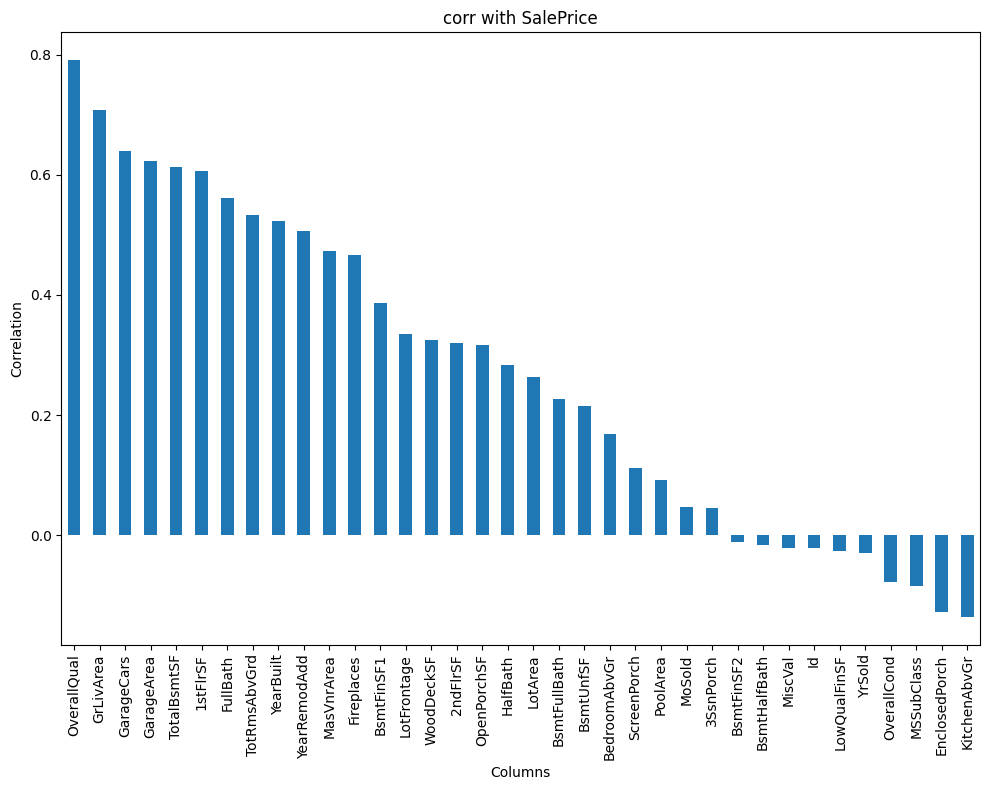

In [189]:
# 'SalePrice' hedef değiskenle ilgili korelasyonlari gormek icin diger ozelliklerle arasindaki iliskilere bakilir.
corr = df.corr(numeric_only=True)['SalePrice'].sort_values(ascending=False)

plt.figure(figsize=(10, 8))
corr.drop('SalePrice').plot(kind='bar')
plt.title('corr with SalePrice')
plt.xlabel('Columns')
plt.ylabel('Correlation')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

OverallQual, GrLivArea, GarageCars, GarageArea, TotalBsmtSF ve 1stFlrSF diğer ozelliklere gore daha SalePrice ile daha yuksek bir pozitif iliski icerisinde. Aykırı değer tespitinde ve modellerde bunlara odaklanılabilir.


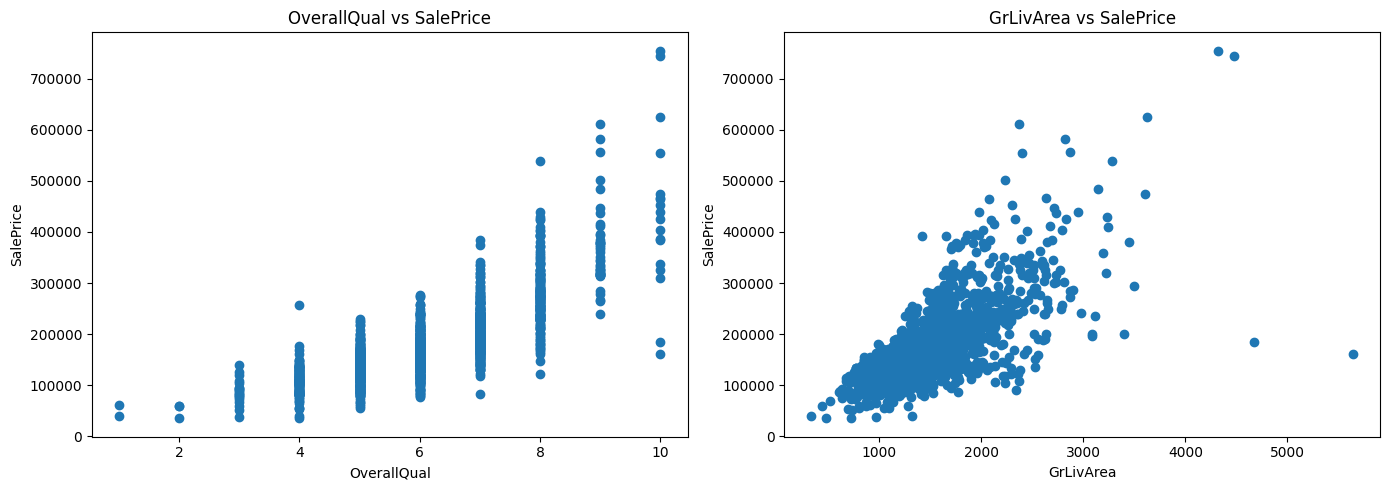

In [190]:
# OverallQual ve GrLivArea icin scatter plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(df['OverallQual'], df['SalePrice'])
axes[0].set_xlabel('OverallQual')
axes[0].set_ylabel('SalePrice')
axes[0].set_title('OverallQual vs SalePrice')

axes[1].scatter(df['GrLivArea'], df['SalePrice'])
axes[1].set_xlabel('GrLivArea')
axes[1].set_ylabel('SalePrice')
axes[1].set_title('GrLivArea vs SalePrice')

plt.tight_layout()
plt.show()

### Değerlendirme
- OverallQual, belirgin bir aykırı değer bulunmuyor, genel trend mantıklı ve yapı için 1 ile 10 arasında sabit sayılarla puanlama yapıldığı için sürekli bir aralık sergilemez.
- GrLivArea, evin zemin üstü yaşam alanı 4000-5000 sürekli aralığında büyük değerlerle ilerlemekte sadece sağ tarafta iki nokta için yaşanabilir alanın artışına rağmen bu noktalarda daha düşük bir fiyatlandırma var yani aykırı değerler bulunmakta. Gerçek piyasa değerini genele bakıldığında yansıtmıyor.

In [191]:
# IQR ile sayisal olarak tespit etme
Q1 = df['GrLivArea'].quantile(0.25)
Q3 = df['GrLivArea'].quantile(0.75)
IQR = Q3 - Q1

alt_sinir = Q1 - 1.5 * IQR
ust_sinir = Q3 + 1.5 * IQR

print(f"Alt sinir: {alt_sinir:.0f}")
print(f"Ust sinir: {ust_sinir:.0f}")
print(f"Aykiri deger sayisi: {((df['GrLivArea'] < alt_sinir) | (df['GrLivArea'] > ust_sinir)).sum()}")

Alt sinir: 159
Ust sinir: 2748
Aykiri deger sayisi: 31


In [192]:
# 31 tane aykiri degere bak
outliers = df[(df['GrLivArea'] < 159) | (df['GrLivArea'] > 2748)]
print(outliers[['GrLivArea', 'SalePrice']].sort_values('GrLivArea', ascending=False))

      GrLivArea  SalePrice
1298       5642     160000
523        4676     184750
1182       4476     745000
691        4316     755000
1169       3627     625000
185        3608     475000
304        3493     295000
1268       3447     381000
635        3395     200000
769        3279     538000
1353       3238     410000
496        3228     430000
118        3222     320000
608        3194     359100
798        3140     485000
197        3112     235000
1173       3086     200500
1031       3082     197000
324        2978     242000
58         2945     438780
1024       2898     287000
961        2872     272000
1175       2872     285000
1046       2868     556581
1142       2828     424870
803        2822     582933
1312       2810     302000
231        2794     403000
1328       2792     256000
1386       2784     250000
583        2775     325000


(1458, 81)




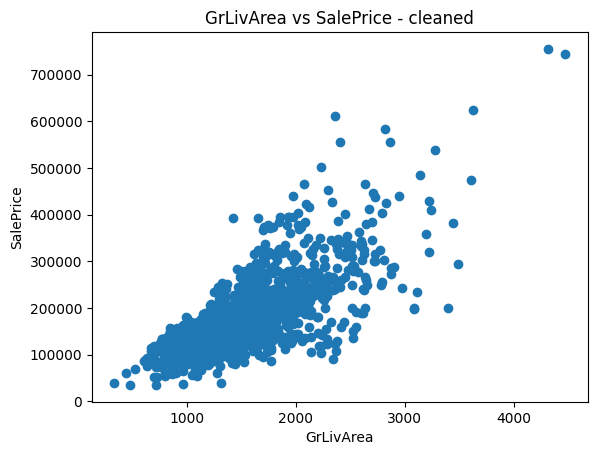

In [193]:
# uygun gorulen iki deger disindakiler kalsin cunku iki degerin fiyatlari digerlernie gore cok dusuk

df = df.drop(df[(df['GrLivArea'] > 4000) & (df['SalePrice'] < 200000)].index)
print(df.shape)

print("\n")

plt.scatter(df['GrLivArea'], df['SalePrice'])
plt.xlabel('GrLivArea')
plt.ylabel('SalePrice')
plt.title('GrLivArea vs SalePrice - cleaned')
plt.show()

In [194]:
# GarageArea, TotalBsmtSF, 1stFlrSF icin IQR uygulama

for col in ['GarageArea', 'TotalBsmtSF', '1stFlrSF']:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    alt = Q1 - 1.5 * IQR
    ust = Q3 + 1.5 * IQR
    aykiri = ((df[col] < alt) | (df[col] > ust)).sum()
    print(f"{col}: alt={alt:.0f}, ust={ust:.0f}, aykiri={aykiri}")

GarageArea: alt=-35, ust=943, aykiri=20
TotalBsmtSF: alt=43, ust=2049, aykiri=59
1stFlrSF: alt=119, ust=2154, aykiri=18


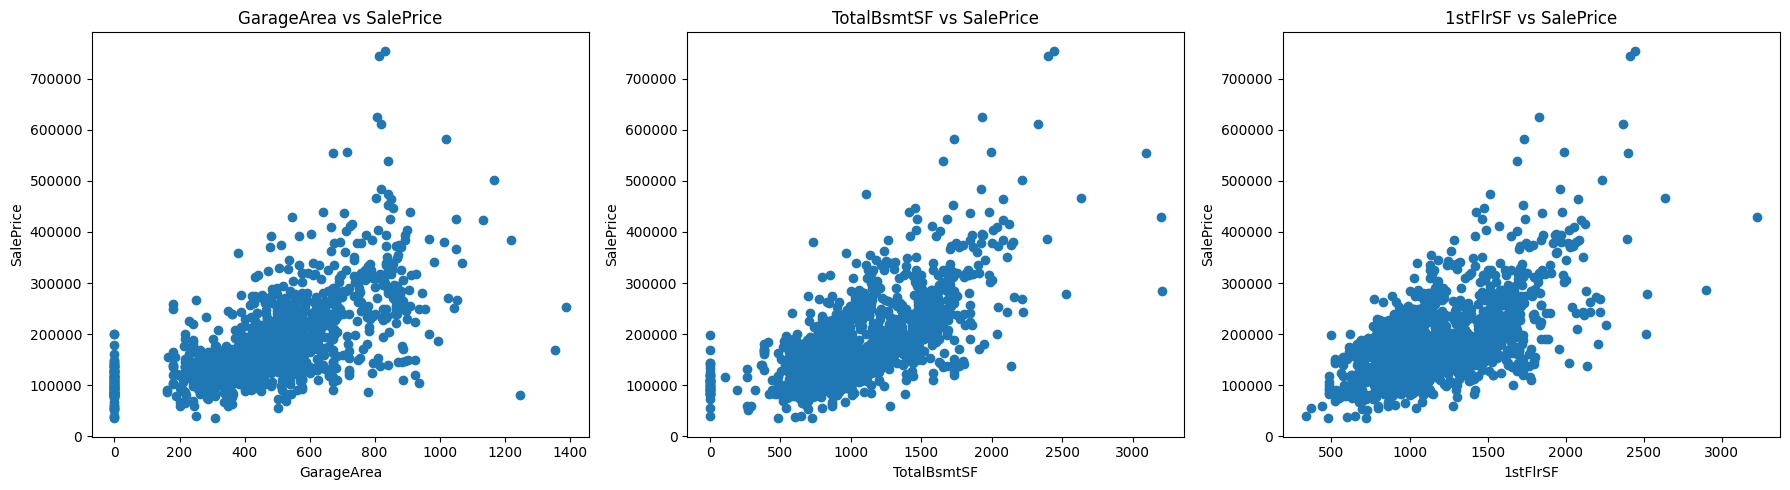

In [195]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, col in enumerate(['GarageArea', 'TotalBsmtSF', '1stFlrSF']):
    axes[i].scatter(df[col], df['SalePrice'])
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('SalePrice')
    axes[i].set_title(f'{col} vs SalePrice')

plt.tight_layout()
plt.show()

## Aykırı Değer Tespiti Sonuçları

### GrLivArea
IQR yöntemi ile 31 aykırı değer tespit edildi.
Scatter plot incelendiğinde 2 bariz anomali görüldü:
alan 4000+ olmasına rağmen fiyatı 200.000$ altında olan evler.
Bu evler muhtemelen özel/zorunlu satış olduğu için
gerçek piyasa değerini yansıtmıyor. 2 satır silindi.

### GarageArea, TotalBsmtSF, 1stFlrSF
IQR yöntemi sırasıyla 20, 59, 18 aykırı değer tespit etti.
Ancak scatter plot incelendiğinde bu noktalar trend'e uygun,
yani büyük alan = yüksek fiyat ilişkisi bozulmuyor.
IQR burada çok agresif davrandı, bu sütunlarda
temizleme yapılmadı.

### Genel Kural
Sadece istatistiksel yöntem yetmez, görsel doğrulama
şarttır. IQR aykırı değer "adayı" gösterir,
karar scatter plot ile verilir.

## Veri Tipi Dönüşümleri

In [196]:
# dtypes.csv olarak klasor icine eklendi
df.dtypes.to_frame().to_csv('dtypes.csv')

In [197]:
# GarageYrBlt ozelliginin tipi object olarak bu degerin float64 yapilması gerekiyor
df['GarageYrBlt'].head(5)

0    2003.0
1    1976.0
2    2001.0
3    1998.0
4    2000.0
Name: GarageYrBlt, dtype: object

In [198]:
# model sayisal degerlerle calisir, object tipini anlayamaz
df['GarageYrBlt'] = pd.to_numeric(df['GarageYrBlt'], errors='coerce')
df['GarageYrBlt'].dtype

dtype('float64')

## Encoding

Makine öğrenmesi modelleri sayısal verilerle çalışır,
kategorik (object) sütunları anlayamaz. Bu yüzden
kategorik sütunların sayısala çevirilmesi gerekiyor.

### Label Encoding
Sıralı kategoriler için kullanılır.
Örneğin: Ex=4, Gd=3, TA=2, Fa=1, Po=0 gibi.

### One-Hot Encoding
Sırasız kategoriler için kullanılır.
Her kategori için yeni bir sütun oluşturur.
Örneğin: MSZoning_RL, MSZoning_RM, MSZoning_RH gibi.

In [199]:
from sklearn.preprocessing import LabelEncoder

# sirali kategoriler manuel mapping
qual_map = {'None': 0, 'Po': 1, 'Fa': 2, 'TA': 3, 'Gd': 4, 'Ex': 5}

qual_cols = ['ExterQual', 'ExterCond', 'BsmtQual', 'BsmtCond', 'HeatingQC', 'KitchenQual', 'FireplaceQu', 'GarageQual', 'GarageCond', 'PoolQC']

for col in qual_cols:
    df[col] = df[col].map(qual_map)

In [200]:
# BsmtExposure
bsmt_exp_map = {'None': 0, 'No': 1, 'Mn': 2, 'Av': 3, 'Gd': 4}
df['BsmtExposure'] = df['BsmtExposure'].map(bsmt_exp_map)

# BsmtFinType1 & BsmtFinType2
bsmt_fin_map = {'None': 0, 'Unf': 1, 'LwQ': 2, 'Rec': 3, 'BLQ': 4, 'ALQ': 5, 'GLQ': 6}
df['BsmtFinType1'] = df['BsmtFinType1'].map(bsmt_fin_map)
df['BsmtFinType2'] = df['BsmtFinType2'].map(bsmt_fin_map)

# GarageFinish
garage_fin_map = {'None': 0, 'Unf': 1, 'RFn': 2, 'Fin': 3}
df['GarageFinish'] = df['GarageFinish'].map(garage_fin_map)

# Fence
fence_map = {'None': 0, 'MnWw': 1, 'GdWo': 2, 'MnPrv': 3, 'GdPrv': 4}
df['Fence'] = df['Fence'].map(fence_map)

# CentralAir
df['CentralAir'] = df['CentralAir'].map({'N': 0, 'Y': 1})

# PavedDrive
df['PavedDrive'] = df['PavedDrive'].map({'N': 0, 'P': 1, 'Y': 2})

In [201]:
one_hot_cols = ['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour',
                'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood',
                'Condition1', 'Condition2', 'BldgType', 'HouseStyle',
                'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd',
                'MasVnrType', 'Foundation', 'Heating', 'Electrical',
                'Functional', 'GarageType', 'MiscFeature', 'SaleType',
                'SaleCondition']

# her kategorinin her degeri icin yeni bir sutun olusturma
df = pd.get_dummies(df, columns=one_hot_cols)
print(df.shape)

(1458, 237)


In [202]:
# object kalan sutun var mi
# hala object kalan sütun var mı?
print(df.select_dtypes(include='object').columns.tolist())

[]


## Feature Engineering

Mevcut sütunlardan yeni, daha anlamlı sütunlar türetme islemi.
Bu yeni sütunlar modelin daha iyi tahmin yapmasına yardımcı olur.

In [203]:
# toplam alan
df['TotalSF'] = df['TotalBsmtSF'] + df['1stFlrSF'] + df['2ndFlrSF']

# evin yasi
df['HouseAge'] = df['YrSold'] - df['YearBuilt']

# yenileme yapil mi?
df['IsRemodeled'] = (df['YearRemodAdd'] != df['YearBuilt']).astype(int)

# toplam banyo sayisi
df['TotalBath'] = df['FullBath'] + df['HalfBath'] + df['BsmtFullBath'] + df['BsmtHalfBath']

# veranda alani
df['TotalPorchSF'] = df['OpenPorchSF'] + df['EnclosedPorch'] + df['3SsnPorch'] + df['ScreenPorch']

print(df[['TotalSF', 'HouseAge', 'IsRemodeled', 'TotalBath', 'TotalPorchSF']].head())

   TotalSF  HouseAge  IsRemodeled  TotalBath  TotalPorchSF
0     2566         5            0          4            61
1     2524        31            0          3             0
2     2706         7            1          4            42
3     2473        91            1          2           307
4     3343         8            0          4            84


## Feature Selection

Modele tüm sütunları vermek her zaman iyi sonuç vermez.
Gereksiz veya düşük ilişkili sütunlar modeli karmaşıklaştırır
ve tahmin hatalarını artırır.

Korelasyon değerine bakarak hangi sütunların SalePrice ile
güçlü ilişkili olduğunu belirlenir.

- Yüksek korelasyon (0.5+) ise modele dahil edilir
- Düşük korelasyon (0.1 altı) ise çıkarılır
- Negatif korelasyon ise mutlak degeri yuksekse modele dahil edilir.


In [204]:
# 0.3+ yveya 0.3- olan ozelliklerin iliskisi orta ve ust seviyelerde toplanir. Modele katkilari yuksek olur.
new_features = ['TotalSF', 'HouseAge', 'IsRemodeled', 'TotalBath', 'TotalPorchSF']

for col in new_features:
    corr = df[col].corr(df['SalePrice'])
    print(f"{col}: {corr:.3f}")

TotalSF: 0.833
HouseAge: -0.524
IsRemodeled: -0.022
TotalBath: 0.617
TotalPorchSF: 0.197


TotalPorchSF diger yeni eklenen ozelliklere gore daha duusk bir korelasyona sahip o yuzden bu ozellik cikarilabilir

In [205]:
# tum satirlarin korelasyonuna bakip modele eklenecekler secilir
corr = df.corr(numeric_only=True)['SalePrice'].abs().sort_values(ascending=False)
print(corr[corr > 0.3])

SalePrice                1.000000
TotalSF                  0.832877
OverallQual              0.795774
GrLivArea                0.734968
ExterQual                0.686756
KitchenQual              0.662236
TotalBsmtSF              0.651153
GarageCars               0.641047
1stFlrSF                 0.631530
GarageArea               0.629217
TotalBath                0.616722
BsmtQual                 0.586674
FullBath                 0.562165
GarageFinish             0.550255
TotRmsAbvGrd             0.537769
HouseAge                 0.524067
YearBuilt                0.523608
YearRemodAdd             0.507717
Foundation_PConc         0.498341
GarageYrBlt              0.487156
MasVnrArea               0.477810
Fireplaces               0.469862
HeatingQC                0.428024
BsmtFinSF1               0.409384
Neighborhood_NridgHt     0.402139
BsmtExposure             0.376660
MasVnrType_None          0.368020
SaleType_New             0.360731
SaleCondition_Partial    0.355162
GarageType_Det

In [206]:
corr = df.corr(numeric_only=True)['SalePrice'].abs().sort_values(ascending=False).to_frame().to_csv('corrs.csv')

In [207]:
corr = df.corr(numeric_only=True)['SalePrice'].sort_values()
print(corr[corr < -0.3])

HouseAge            -0.524067
MasVnrType_None     -0.368020
GarageType_Detchd   -0.354326
Foundation_CBlock   -0.343582
Name: SalePrice, dtype: float64


In [208]:
# secilen ozellikleri listeye ekle
selected_features = [
    'TotalSF', 'OverallQual', 'GrLivArea', 'ExterQual', 'KitchenQual',
    'TotalBsmtSF', 'GarageCars', '1stFlrSF', 'GarageArea', 'TotalBath',
    'BsmtQual', 'FullBath', 'GarageFinish', 'TotRmsAbvGrd', 'HouseAge',
    'YearBuilt', 'YearRemodAdd', 'GarageYrBlt', 'MasVnrArea', 'Fireplaces',
    'HeatingQC', 'BsmtFinSF1', 'BsmtExposure', 'LotFrontage', 'WoodDeckSF',
    'OpenPorchSF', '2ndFlrSF', 'BsmtFinType1', 'MasVnrType_None',
    'GarageType_Detchd', 'Foundation_CBlock'
]

X = df[selected_features]
y = df['SalePrice']

print(X.shape)

(1458, 31)


In [209]:
print(X.isnull().sum()[X.isnull().sum() > 0])

GarageYrBlt    81
dtype: int64


In [210]:
X['GarageYrBlt'] = X['GarageYrBlt'].fillna(X['GarageYrBlt'].median())
print(X.isnull().sum().sum())

0


/tmp/ipykernel_107592/4278589651.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['GarageYrBlt'] = X['GarageYrBlt'].fillna(X['GarageYrBlt'].median())


## Model Kurma

Önce Linear Regression ile baz model kur.
Sonra Polynomial Regression ile karşılaştır.

- Linear Regression: düz çizgi ile tahmin
- Polynomial Regression: eğri ile tahmin, daha karmaşık ilişkileri yakalar

In [239]:
# veriyi karistir  - train_test_split'in arka planda yaptığı şey
np.random.seed(42)
indices = np.random.permutation(len(X))

# 0.8 train, 0.2 test
train_size = int(len(X)*0.8)
train_idx = indices[:train_size]
test_idx = indices[train_size:]

# X'in train_idx sıralarındaki satırlarını al → train seti
X_train = X.iloc[train_idx]

# X'in test_idx sıralarındaki satırlarını al → test seti
X_test = X.iloc[test_idx]

# y'nin train_idx sıralarındaki değerlerini al → train etiketleri
y_train = y.iloc[train_idx]

# y'nin test_idx sıralarındaki değerlerini al → test etiketleri
y_test = y.iloc[test_idx]

print(f"Train: {X_train.shape}")
print(f"Test: {X_test.shape}")

Train: (1166, 31)
Test: (292, 31)


In [240]:
# Model eğitimine başlamadan hemen önce hedef değişkenin logaritmasını al
y_log = np.log1p(y) 

# Artık y yerine y_log kullanacağız
# X_train, X_test zaten ayrılmıştı, şimdi y_train ve y_test'i de logaritmik yapmalısın:
y_train_log = np.log1p(y_train)
y_test_log = np.log1p(y_test)

In [242]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score

# Modelleri tanımlıyoruz
models = {
    "Linear": LinearRegression(),
    "Ridge": make_pipeline(StandardScaler(), Ridge(alpha=10)),
    "Lasso": make_pipeline(StandardScaler(), Lasso(alpha=0.001)),
    "RandomForest": RandomForestRegressor(n_estimators=200, random_state=42),
    "GradientBoosting": GradientBoostingRegressor(n_estimators=200, learning_rate=0.05, random_state=42),
}

Linear modeli tamamlandı. R²: 0.8856
Ridge modeli tamamlandı. R²: 0.8890
Lasso modeli tamamlandı. R²: 0.8886
RandomForest modeli tamamlandı. R²: 0.8755
GradientBoosting modeli tamamlandı. R²: 0.8736


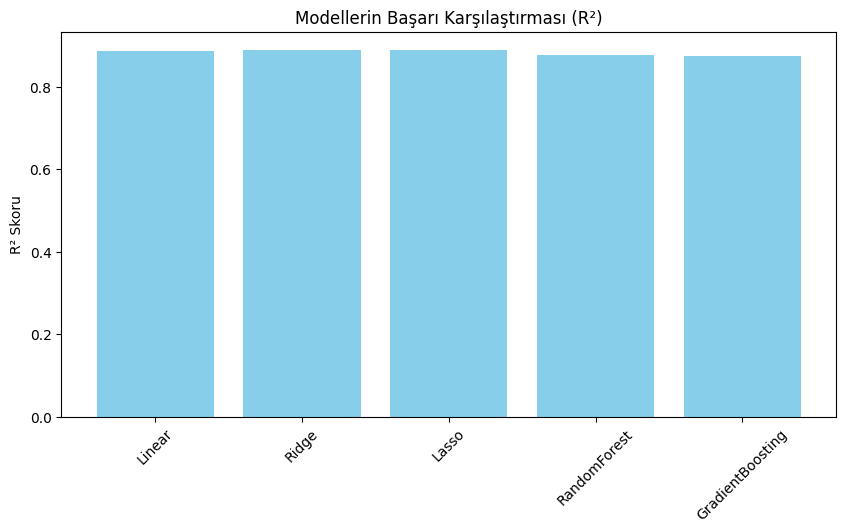

In [243]:
results = {}

for name, model in models.items():
    model.fit(X_train, y_train_log)
    preds = model.predict(X_test)
    r2 = r2_score(y_test, np.expm1(preds))
    results[name] = r2
    print(f"{name} modeli tamamlandı. R²: {r2:.4f}")

# Karşılaştırma grafiği
plt.figure(figsize=(10, 5))
plt.bar(results.keys(), results.values(), color='skyblue')
plt.title('Modellerin Başarı Karşılaştırması (R²)')
plt.ylabel('R² Skoru')
plt.xticks(rotation=45)
plt.show()

In [244]:
# En iyi modeli seç
best_model_name = max(results, key=results.get)
best_model = models[best_model_name]
print(f"En iyi model seçildi: {best_model_name}")

# Tüm train verisiyle tekrar eğit (Daha iyi genelleme için)
best_model.fit(X, np.log1p(y))

En iyi model seçildi: Ridge


Pipeline(steps=[('standardscaler', StandardScaler()),
                ('ridge', Ridge(alpha=10))])

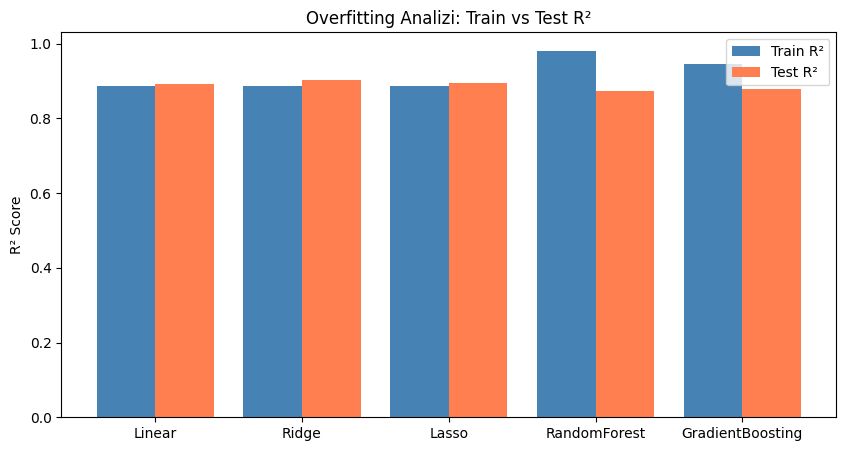

In [245]:
# Her model için Train ve Test skorlarını saklayalım
train_scores = []
test_scores = []

for name, model in models.items():
    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)
    
    train_scores.append(r2_score(y_train_log, train_pred))
    test_scores.append(r2_score(y_test_log, test_pred))

# Grafiği çizdir
x = np.arange(len(models))
plt.figure(figsize=(10, 5))
plt.bar(x - 0.2, train_scores, 0.4, label='Train R²', color='steelblue')
plt.bar(x + 0.2, test_scores, 0.4, label='Test R²', color='coral')
plt.xticks(x, models.keys())
plt.ylabel('R² Score')
plt.title('Overfitting Analizi: Train vs Test R²')
plt.legend()
plt.show()

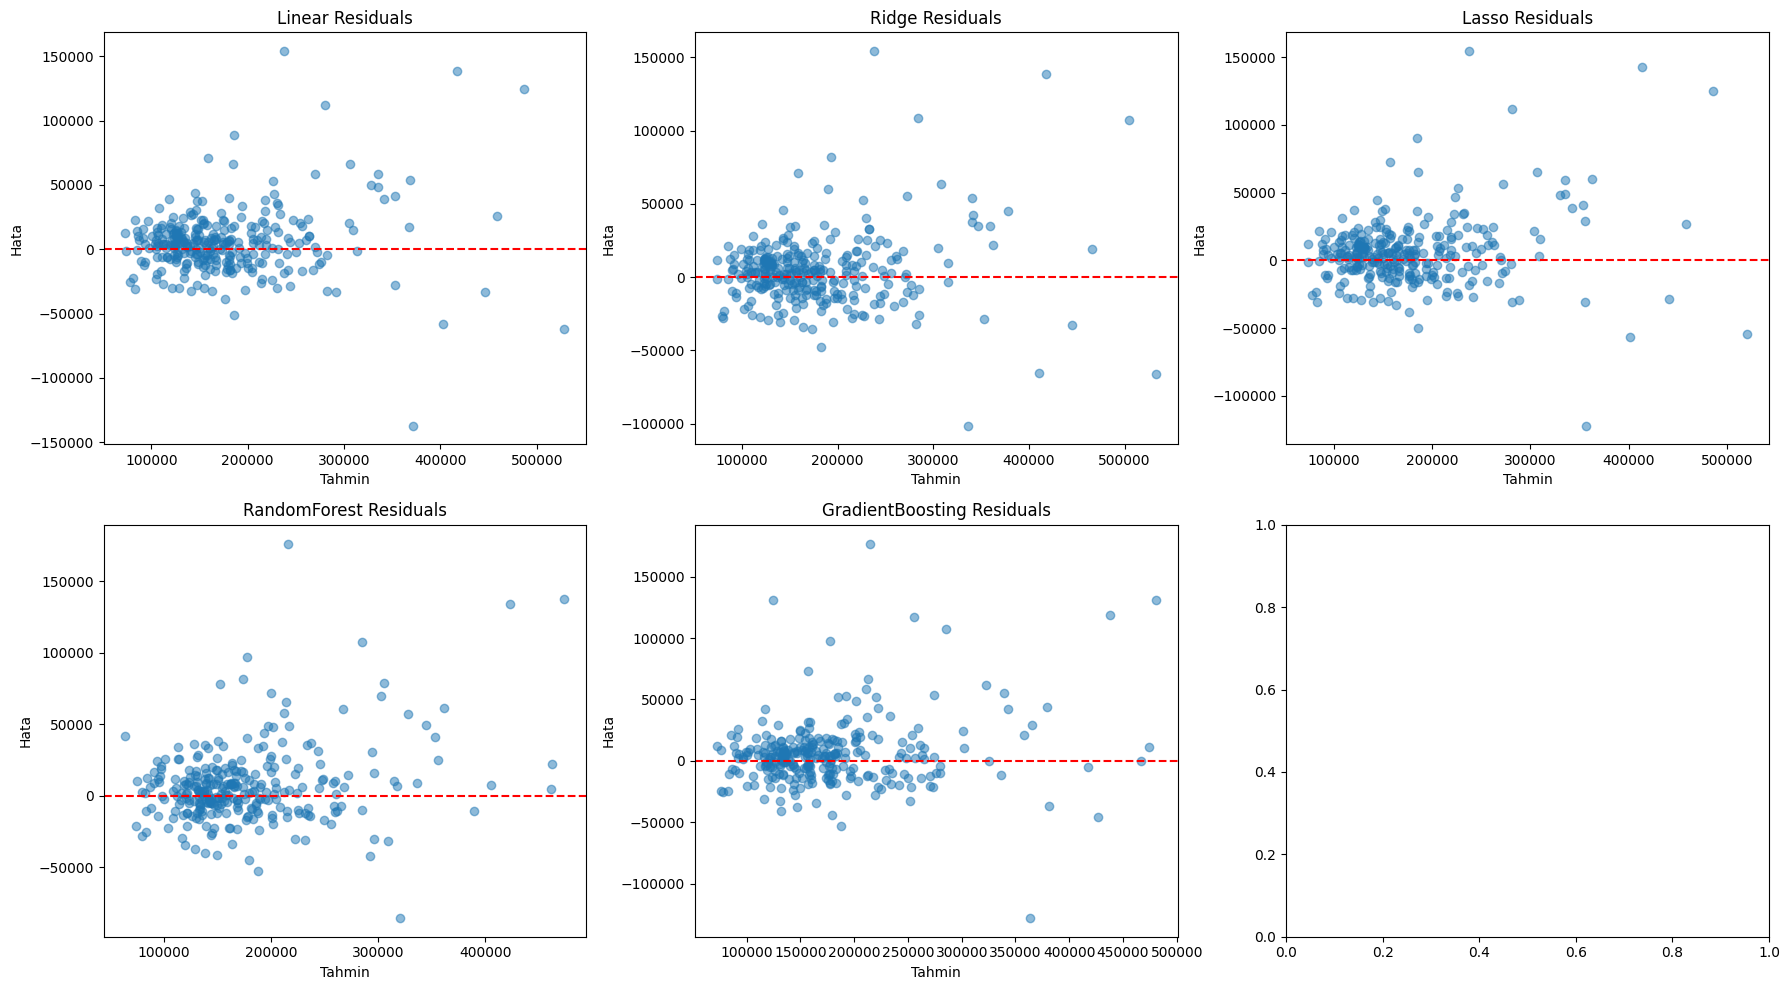

In [248]:
# 3x2'lik bir grafik alanı oluşturalım
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, (name, model) in enumerate(models.items()):
    # Tahminler
    preds = model.predict(X_test)
    preds_exp = np.expm1(preds) 
    y_test_exp = np.expm1(y_test_log)
    residuals = y_test_exp - preds_exp
    
    # Grafik
    axes[i].scatter(preds_exp, residuals, alpha=0.5)
    axes[i].axhline(y=0, color='r', linestyle='--')
    axes[i].set_title(f'{name} Residuals')
    axes[i].set_xlabel('Tahmin')
    axes[i].set_ylabel('Hata')

plt.tight_layout()
plt.show()

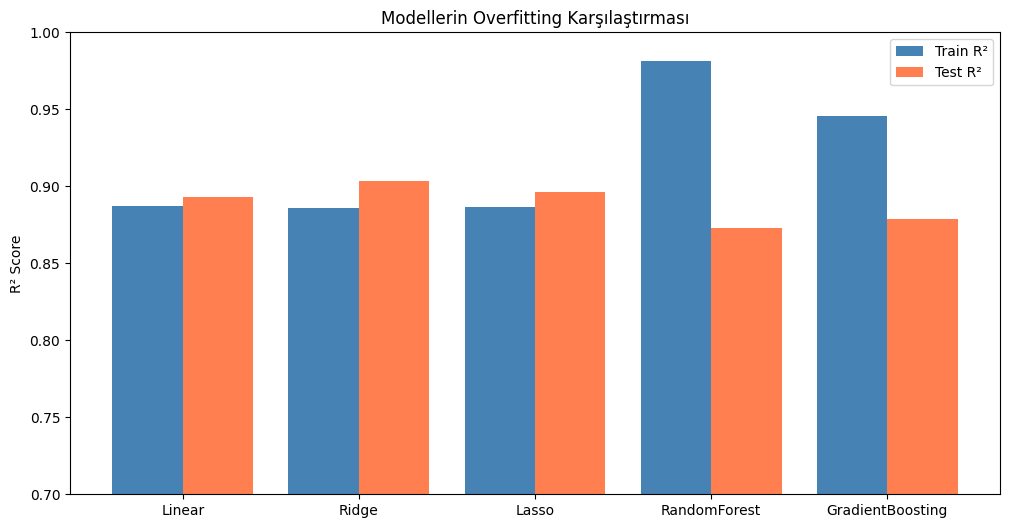

In [249]:
train_scores = []
test_scores = []

for name, model in models.items():
    train_scores.append(r2_score(y_train_log, model.predict(X_train)))
    test_scores.append(r2_score(y_test_log, model.predict(X_test)))

# Bar grafiği
x = np.arange(len(models))
plt.figure(figsize=(12, 6))
plt.bar(x - 0.2, train_scores, 0.4, label='Train R²', color='steelblue')
plt.bar(x + 0.2, test_scores, 0.4, label='Test R²', color='coral')
plt.xticks(x, models.keys())
plt.ylabel('R² Score')
plt.title('Modellerin Overfitting Karşılaştırması')
plt.legend()
plt.ylim(0.7, 1.0) # Farkları net görmek için
plt.show()

# Model Analizi ve Seçim Raporu

### 1. Modellerin Analizi (Overfitting ve Residuals)
Analiz sonucunda elde edilen veriler şu şekildedir:

* **Overfitting Kontrolü:** Ridge ve Lasso gibi lineer modeller, Train ve Test R² skorlarının birbirine yakın olmasıyla "genellenebilir" ve "iyi" oldukları görülmektedir.
* **Residuals (Hata) Analizi:** Hata grafiklerindeki homojen ve rastgele dağılım, modellerin verideki temel trendi başarılı bir şekilde öğrendiğini, sistematik bir hata yapmadığını göstermektedir.
* **Sonuç:** RandomForest ve GradientBoosting modelleri yüksek Train skoru verse de Test setinde performans düşüşü yaşadığı için "overfit" (ezberleme) yapmıştır. Bu nedenle en güvenilir ve dengeli model **Ridge** olarak belirlenmiştir.


In [252]:
# Final İşlemi:
# 1. En güvenilir modelimiz olan Ridge'i seçiyoruz.
best_model = models['Ridge']

# 2. Test verisini yükleyip aynı ön işleme adımlarını uyguluyoruz.
import sys
sys.path.append('..')
from src.data_preprocessing import fill_missing_values, encode_features, add_features

df_test = pd.read_csv("../data/raw/test.csv")
df_test = fill_missing_values(df_test)
df_test = encode_features(df_test)
df_test = add_features(df_test)

selected_features = [
    'TotalSF', 'OverallQual', 'GrLivArea', 'ExterQual', 'KitchenQual',
    'TotalBsmtSF', 'GarageCars', '1stFlrSF', 'GarageArea', 'TotalBath',
    'BsmtQual', 'FullBath', 'GarageFinish', 'TotRmsAbvGrd', 'HouseAge',
    'YearBuilt', 'YearRemodAdd', 'GarageYrBlt', 'MasVnrArea', 'Fireplaces',
    'HeatingQC', 'BsmtFinSF1', 'BsmtExposure', 'LotFrontage', 'WoodDeckSF',
    'OpenPorchSF', '2ndFlrSF', 'BsmtFinType1', 'MasVnrType_None',
    'GarageType_Detchd', 'Foundation_CBlock',
]

X_test_final = df_test.reindex(columns=selected_features, fill_value=0)
X_test_final = X_test_final.fillna(0)

# 3. Tüm train verisini kullanarak Ridge modelini son kez eğitiyoruz.
best_model.fit(X, np.log1p(y))

# 4. Test verisi üzerinde final tahminlerimizi yapıyoruz.
final_preds = np.expm1(best_model.predict(X_test_final))

# 5. Tahminleri ID ile birleştirip CSV formatında kaydediyoruz.
submission = pd.DataFrame({'Id': df_test['Id'], 'SalePrice': final_preds})
submission.to_csv('final_submission.csv', index=False)

print("İşlem Başarılı: 'final_submission.csv' dosyası oluşturuldu.")

İşlem Başarılı: 'final_submission.csv' dosyası oluşturuldu.


# Final Model ve Submission Raporu

### 1. Model Seçimi
Analizler sonucunda en güvenilir ve genellenebilir performansı sergileyen **Ridge** modeli final model olarak seçilmiştir.

### 2. Final Süreci
* **Eğitim:** En iyi model olan Ridge, tüm eğitim verisi (X ve y) kullanılarak logaritmik dönüşümle (log1p) tekrar eğitilmiştir.
* **Tahmin:** Test verisi, eğitim verisindeki tüm ön işleme ve mühendislik adımlarından geçirilmiş (hizalama sağlanmıştır) ve final tahminler gerçekleştirilmiştir.
* **Dönüşüm:** Tahmin edilen logaritmik değerler `np.expm1` ile gerçek fiyat ölçeğine döndürülmüştür.

### 3. Sonuç
Tahminler, `Id` sütunu ile eşleştirilerek `final_submission.csv` dosyasına kaydedilmiştir.